# Week 3 — Thursday: Segmentation

## Learning Objectives
- Understand adaptive thresholding
- Learn Watershed algorithm for marker-based segmentation
- Explore GrabCut for interactive segmentation
- Handle touching objects and complex scenes

## Key Concepts
1. **Adaptive Thresholding**: Local threshold computation
2. **Watershed Algorithm**: Marker-based morphological segmentation
3. **GrabCut**: Interactive foreground/background separation
4. **Distance Transform**: Euclidean distance maps
5. **Morphological Segmentation**: Dilation + erosion for marker creation

## Section 1: Adaptive Thresholding

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

### 1.1 Problem with Global Thresholding

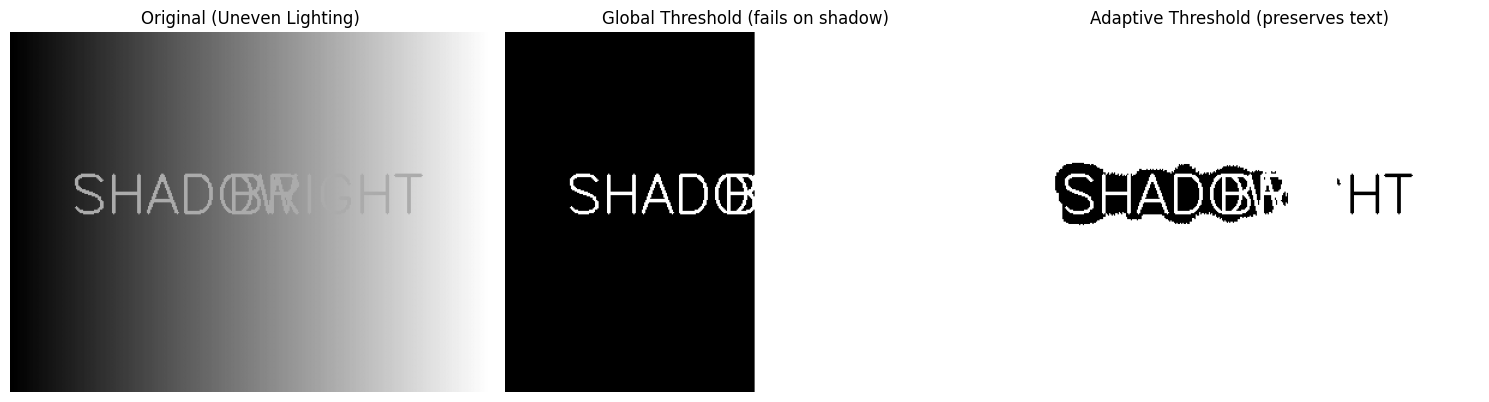

Adaptive thresholding advantages:
- Handles non-uniform lighting
- Computes threshold for each block independently
- Better for documents, photos with shadows


In [2]:
# Create image with varying illumination
img = np.zeros((300, 400), dtype=np.uint8)
# Left side darker, right side brighter
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        img[i, j] = int(50 + (j / img.shape[1]) * 150)

# Add text
cv2.putText(img, 'SHADOW', (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 150, 2)
cv2.putText(img, 'BRIGHT', (180, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 150, 2)

# Global thresholding
_, global_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY, blockSize=21, C=5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Uneven Lighting)')
axes[0].axis('off')

axes[1].imshow(global_thresh, cmap='gray')
axes[1].set_title('Global Threshold (fails on shadow)')
axes[1].axis('off')

axes[2].imshow(adaptive_thresh, cmap='gray')
axes[2].set_title('Adaptive Threshold (preserves text)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print("Adaptive thresholding advantages:")
print("- Handles non-uniform lighting")
print("- Computes threshold for each block independently")
print("- Better for documents, photos with shadows")

### 1.2 Adaptive Threshold Methods

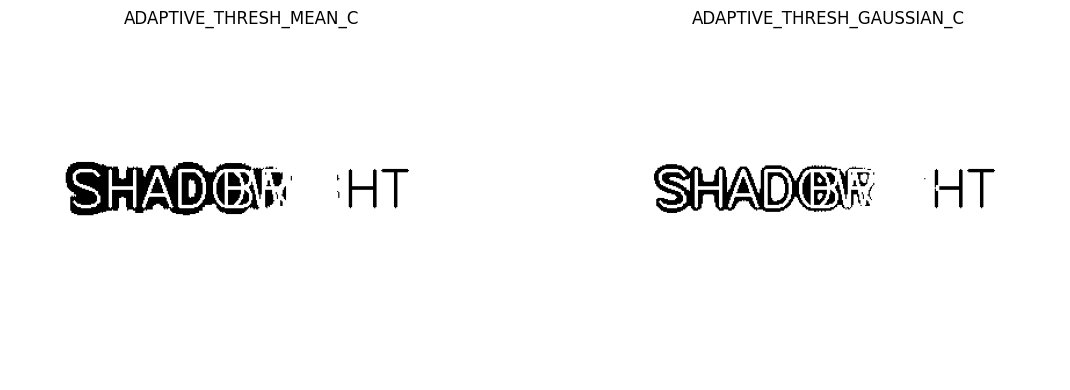

In [3]:
# Two methods for computing adaptive threshold
# ADAPTIVE_THRESH_MEAN_C: T = mean of neighborhood - C
# ADAPTIVE_THRESH_GAUSSIAN_C: T = gaussian-weighted sum - C

adaptive_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, blockSize=15, C=5)

adaptive_gaussian = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv2.THRESH_BINARY, blockSize=15, C=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(adaptive_mean, cmap='gray')
axes[0].set_title('ADAPTIVE_THRESH_MEAN_C')
axes[0].axis('off')

axes[1].imshow(adaptive_gaussian, cmap='gray')
axes[1].set_title('ADAPTIVE_THRESH_GAUSSIAN_C')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Section 2: Distance Transform

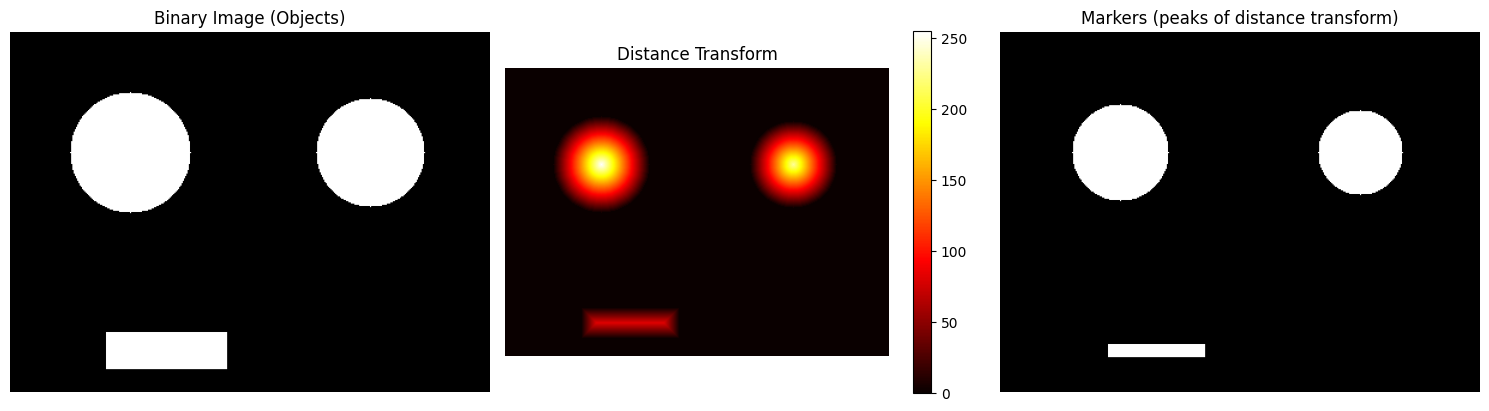

In [4]:
# Distance transform: computes distance of each pixel to nearest background
# Useful for finding seeds/markers for Watershed

# Create binary image with multiple objects
binary_img = np.zeros((300, 400), dtype=np.uint8)
cv2.circle(binary_img, (100, 100), 50, 255, -1)
cv2.circle(binary_img, (300, 100), 45, 255, -1)
cv2.rectangle(binary_img, (80, 250), (180, 280), 255, -1)

# Distance transform
dist_transform = cv2.distanceTransform(binary_img, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title('Binary Image (Objects)')
axes[0].axis('off')

axes[1].imshow(dist_norm, cmap='hot')
axes[1].set_title('Distance Transform')
axes[1].axis('off')
cbar = plt.colorbar(axes[1].imshow(dist_norm, cmap='hot'), ax=axes[1])

# Find peaks (local maxima) as markers
_, markers = cv2.threshold(dist_norm, 50, 255, cv2.THRESH_BINARY)
axes[2].imshow(markers, cmap='gray')
axes[2].set_title('Markers (peaks of distance transform)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Section 3: Watershed Algorithm

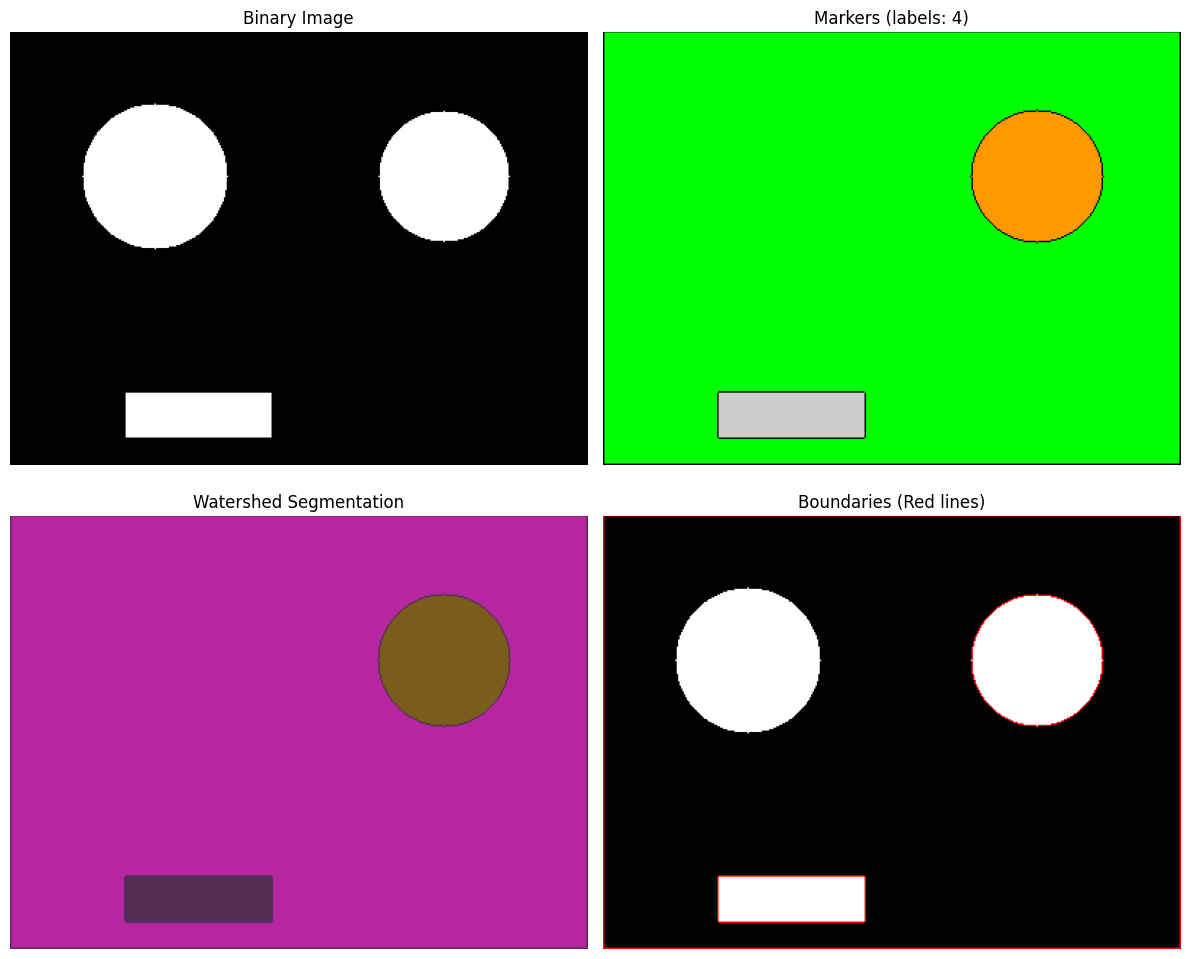

Number of segments: 4
Watershed boundaries marked as: -1 (shown in red)


In [5]:
# Watershed: Segments image by treating it as topographic surface
# Markers = local minima (seeds)
# Algorithm: Water fills up, boundaries form where waters meet

# Create RGB version for watershed
rgb_img = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)

# Get markers
_, markers = cv2.threshold(dist_norm, 50, 255, cv2.THRESH_BINARY)

# Connected components to label markers
num_labels, labeled_markers = cv2.connectedComponents(markers.astype(np.uint8))

# Add background label (important!)
labeled_markers = labeled_markers + 1
labeled_markers[markers == 0] = 0

# Apply watershed
rgb_img_for_watershed = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)
segmented = cv2.watershed(rgb_img_for_watershed, labeled_markers)

# Visualize
# Create colored segmentation
colors = np.random.randint(0, 255, (num_labels + 1, 3))
colors[0] = [0, 0, 0]  # background
colored_segments = colors[labeled_markers]

# Mark boundaries
boundary_img = rgb_img_for_watershed.copy()
boundary_img[segmented == -1] = [0, 0, 255]  # Red boundaries

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(binary_img, cmap='gray')
axes[0, 0].set_title('Binary Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(labeled_markers, cmap='nipy_spectral')
axes[0, 1].set_title(f'Markers (labels: {num_labels})')
axes[0, 1].axis('off')

axes[1, 0].imshow(colored_segments)
axes[1, 0].set_title('Watershed Segmentation')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(boundary_img, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Boundaries (Red lines)')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

print(f"Number of segments: {num_labels}")
print(f"Watershed boundaries marked as: -1 (shown in red)")

## Section 4: Touching Objects Separation

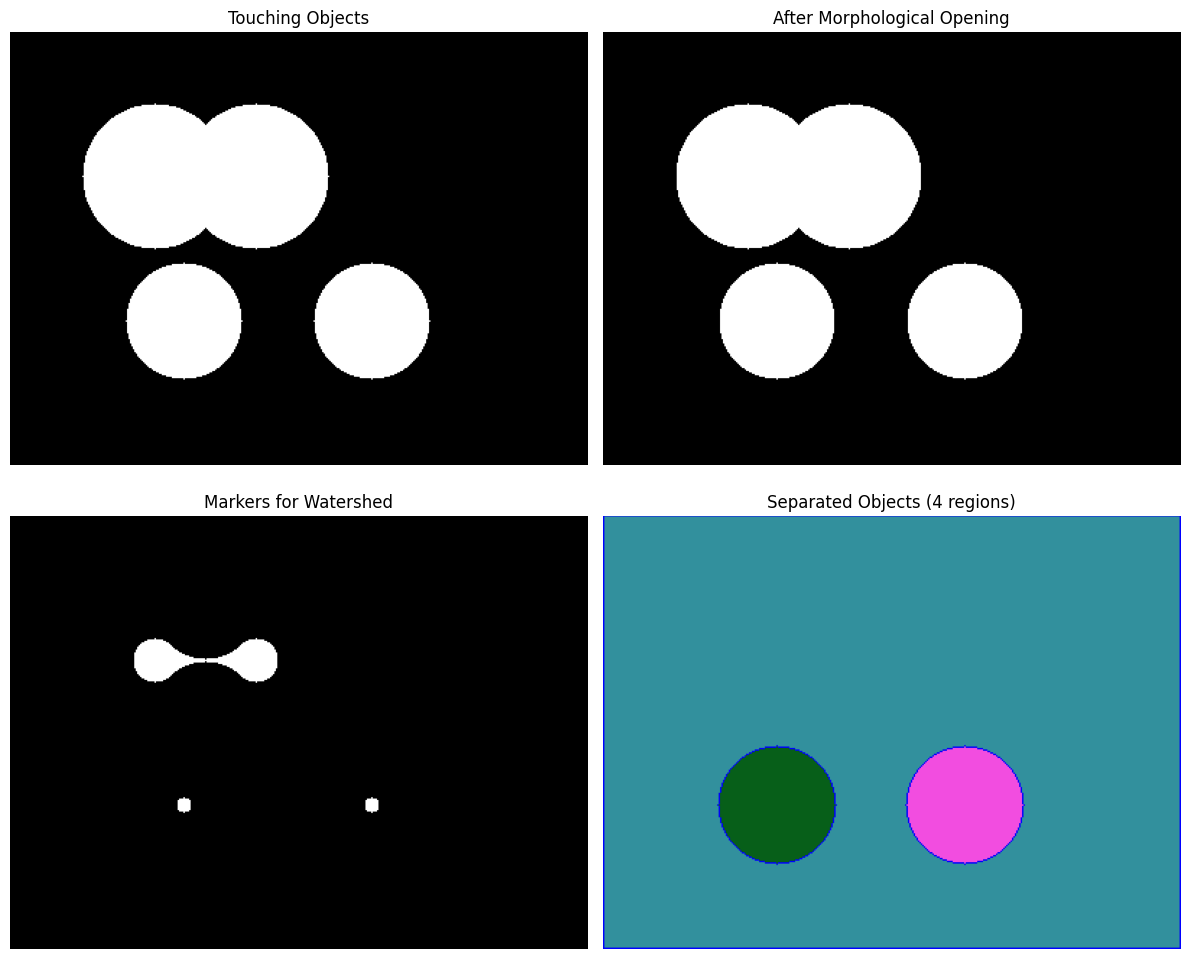

In [6]:
# Create image with touching objects
touching_img = np.zeros((300, 400), dtype=np.uint8)
cv2.circle(touching_img, (100, 100), 50, 255, -1)
cv2.circle(touching_img, (170, 100), 50, 255, -1)  # Overlapping
cv2.circle(touching_img, (120, 200), 40, 255, -1)
cv2.circle(touching_img, (250, 200), 40, 255, -1)

# Morphological opening to separate
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opening = cv2.morphologyEx(touching_img, cv2.MORPH_OPEN, kernel, iterations=2)

# Distance transform for markers
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
_, markers = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, cv2.THRESH_BINARY)

# Watershed
num_labels, labeled_markers = cv2.connectedComponents(markers.astype(np.uint8))
labeled_markers = labeled_markers + 1
labeled_markers[markers == 0] = 0

rgb_img = cv2.cvtColor(touching_img, cv2.COLOR_GRAY2BGR)
segmented = cv2.watershed(rgb_img, labeled_markers)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(touching_img, cmap='gray')
axes[0, 0].set_title('Touching Objects')
axes[0, 0].axis('off')

axes[0, 1].imshow(opening, cmap='gray')
axes[0, 1].set_title('After Morphological Opening')
axes[0, 1].axis('off')

axes[1, 0].imshow(markers, cmap='gray')
axes[1, 0].set_title('Markers for Watershed')
axes[1, 0].axis('off')

# Colored segmentation
colors = np.random.randint(0, 255, (num_labels + 1, 3))
colors[0] = [0, 0, 0]
colored = colors[labeled_markers]
colored[segmented == -1] = [0, 0, 255]

axes[1, 1].imshow(colored)
axes[1, 1].set_title(f'Separated Objects ({num_labels} regions)')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

## Section 5: GrabCut Algorithm

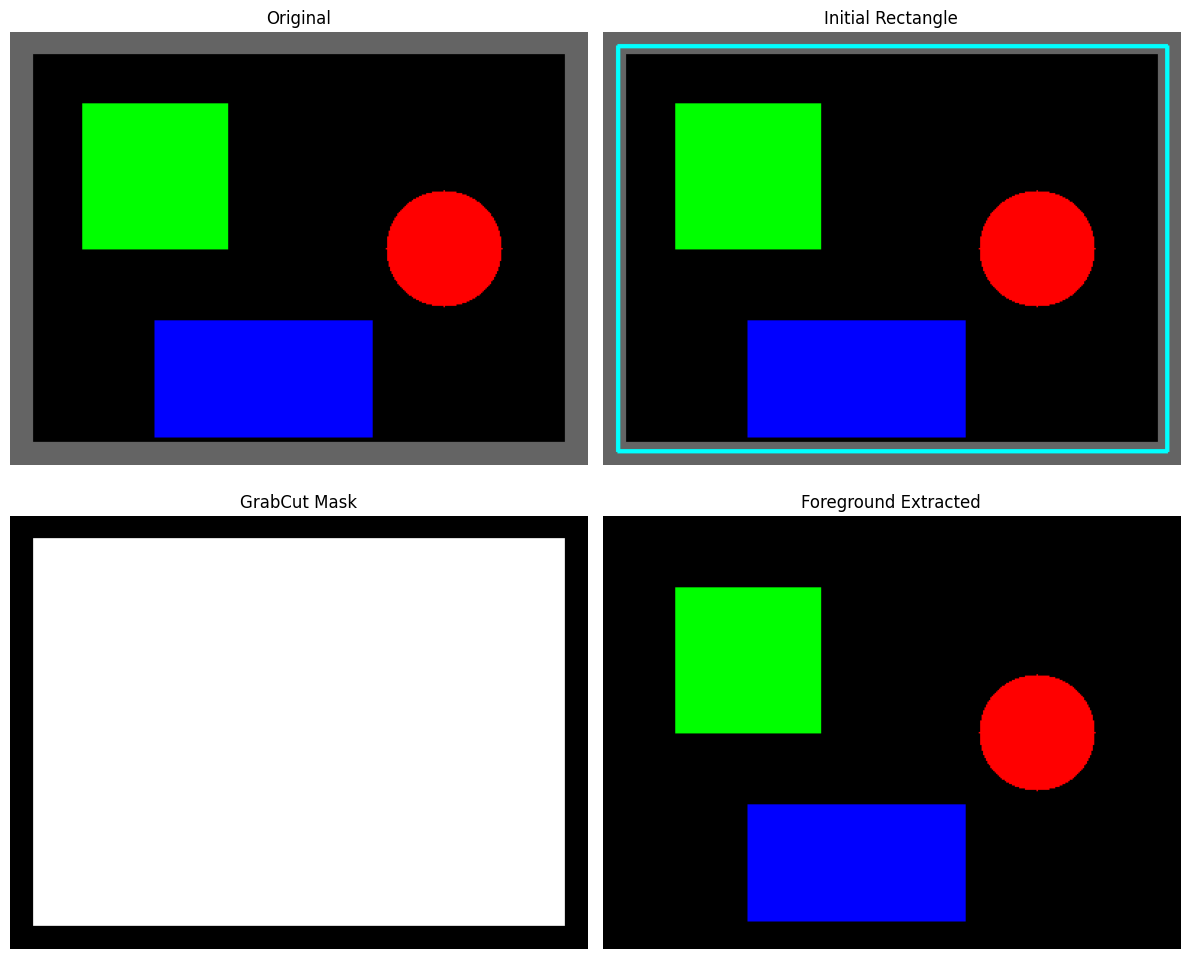

GrabCut Results:
  FGD (Definite FG): 0 pixels
  PR_FGD (Probable FG): 98624 pixels
  BGD (Definite BG): 13600 pixels
  PR_BGD (Probable BG): 7776 pixels


In [7]:
# GrabCut: Interactive foreground-background separation using graph cuts
# Requires initial rectangular mask

# Create image with objects
grabcut_img = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.rectangle(grabcut_img, (50, 50), (150, 150), (0, 255, 0), -1)
cv2.circle(grabcut_img, (300, 150), 40, (0, 0, 255), -1)
cv2.rectangle(grabcut_img, (100, 200), (250, 280), (255, 0, 0), -1)

# Add background
cv2.rectangle(grabcut_img, (0, 0), (399, 299), (100, 100, 100), 30)

# Initialize mask and model
mask = np.zeros(grabcut_img.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Rectangle containing foreground (x, y, width, height)
rect = (10, 10, 380, 280)

# Apply GrabCut
cv2.grabCut(grabcut_img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Create binary mask: probable foreground + definite foreground
output_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype('uint8')

# Apply mask to image
result = cv2.bitwise_and(grabcut_img, grabcut_img, mask=output_mask)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(cv2.cvtColor(grabcut_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

rect_img = grabcut_img.copy()
cv2.rectangle(rect_img, (rect[0], rect[1]), (rect[0]+rect[2], rect[1]+rect[3]), (255, 255, 0), 2)
axes[0, 1].imshow(cv2.cvtColor(rect_img, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Initial Rectangle')
axes[0, 1].axis('off')

axes[1, 0].imshow(output_mask, cmap='gray')
axes[1, 0].set_title('GrabCut Mask')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Foreground Extracted')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

print("GrabCut Results:")
print(f"  FGD (Definite FG): {np.sum(mask == cv2.GC_FGD)} pixels")
print(f"  PR_FGD (Probable FG): {np.sum(mask == cv2.GC_PR_FGD)} pixels")
print(f"  BGD (Definite BG): {np.sum(mask == cv2.GC_BGD)} pixels")
print(f"  PR_BGD (Probable BG): {np.sum(mask == cv2.GC_PR_BGD)} pixels")

## Section 6: Comparison

In [8]:
print("\nSegmentation Methods Comparison:")
print("\n1. Adaptive Thresholding:")
print("   - Best for: Binarization with non-uniform lighting")
print("   - Speed: Very fast")
print("   - Requires: Binary foreground/background")

print("\n2. Watershed:")
print("   - Best for: Separating touching objects")
print("   - Speed: Medium")
print("   - Requires: Good markers (seed points)")

print("\n3. GrabCut:")
print("   - Best for: Interactive foreground extraction")
print("   - Speed: Slower (iterative)")
print("   - Requires: Initial bounding rectangle")
print("   - Can be refined with user input")


Segmentation Methods Comparison:

1. Adaptive Thresholding:
   - Best for: Binarization with non-uniform lighting
   - Speed: Very fast
   - Requires: Binary foreground/background

2. Watershed:
   - Best for: Separating touching objects
   - Speed: Medium
   - Requires: Good markers (seed points)

3. GrabCut:
   - Best for: Interactive foreground extraction
   - Speed: Slower (iterative)
   - Requires: Initial bounding rectangle
   - Can be refined with user input


## Section 7: Key Takeaways

1. **Adaptive Thresholding**: Handles varying illumination
2. **Distance Transform**: Creates markers for seed-based segmentation
3. **Watershed**: Topographic approach to segment touching objects
4. **GrabCut**: Graph-cut based interactive segmentation
5. **Pipeline**: Preprocessing → Markers → Watershed → Post-processing
6. **Applications**: Medical imaging, object counting, foreground extraction

## Exercises

1. Implement an automatic marker generation using morphological operations.
2. Create a function to refine GrabCut results interactively.
3. Build a system to count and label individual objects separated by Watershed.
4. Combine adaptive thresholding + Watershed for robust object segmentation.